<a href="https://colab.research.google.com/github/Florenciacorta/Syllabus/blob/main/C2/E1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# IIC2115 — Programación como Herramienta  
## Ejercicio Formativo 1 — Capítulo 2

**Estudiante:** Florencia Corta  
**Archivo:** `C2/E1.ipynb`

**Propósito:** explorar estadística y visualmente los 4 conjuntos del “Anscombe’s quartet”.  
**Formato de trabajo:** celdas separadas por subtarea; comentarios breves y resultados visibles.


In [ ]:
import pandas as pd
from google.colab import files
import io

# 1) Subir archivo manualmente
uploaded = files.upload()

# 2) Leer con pandas
fname = next(iter(uploaded))
df = pd.read_csv(io.BytesIO(uploaded[fname]))

print("Forma:", df.shape)
print("\nColumnas:", list(df.columns))
print("\nPrimeras filas:")
display(df.head())

print("\nInfo dtypes:")
print(df.info())


Saving E1_data.csv to E1_data.csv
Forma: (44, 3)

Columnas: ['X', 'Y', 'Set']

Primeras filas:


,X,Y,Set
0,8,6.58,A
1,8,5.76,A
2,8,7.71,A
3,8,8.84,A
4,8,8.47,A



Info dtypes:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44 entries, 0 to 43
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   X       44 non-null     int64  
 1   Y       44 non-null     float64
 2   Set     44 non-null     object 
dtypes: float64(1), int64(1), object(1)
memory usage: 1.2+ KB
None


### Comentario sobre el formato de los datos
El CSV viene en formato “largo/tidy”: cada fila es un par (x, y) y una etiqueta de conjunto (A, B, C o D).  
Esto facilita agrupar por conjunto y calcular métricas separadas. Si la columna de etiqueta se llama
por ejemplo `set`/`series`/`conjunto`, puedo usar `groupby` para operar por A–D.


## Paso 4 — Métricas por conjunto (A–D)
**Objetivo:** calcular métricas por grupo para comparar los 4 conjuntos de Anscombe.  
**Métricas:** n, media y desviación de x e y, mínimos/máximos y correlación x–y.  
**Salida esperada:** una tabla con una fila por conjunto (A–D) y columnas con las métricas.


In [ ]:
import re
import pandas as pd

def normalizar_anscombe_v2(df):
    # Mapa: minúscula -> nombre original
    cols_lower = {c.lower(): c for c in df.columns}

    # 1) Caso "largo": ya hay una columna de grupo + x + y (en cualquier mayúsc/minúsc)
    group_candidates = ['conjunto','dataset','series','set','group','grupo']
    group_key = next((g for g in group_candidates if g in cols_lower), None)
    if group_key and ('x' in cols_lower and 'y' in cols_lower):
        return df.rename(columns={
            cols_lower[group_key]: 'conjunto',
            cols_lower['x']: 'x',
            cols_lower['y']: 'y',
        })[['conjunto','x','y']].copy()

    # 2) Caso "ancho": X1..X4 / Y1..Y4 (cualquier mayúsc/minúsc)
    x_cols = [c for c in df.columns if re.fullmatch(r'[xX]\d+', c)]
    y_cols = [c for c in df.columns if re.fullmatch(r'[yY]\d+', c)]
    if x_cols and y_cols and len(x_cols) == len(y_cols):
        tmp = df.copy()
        tmp['__id__'] = range(len(tmp))
        long = pd.wide_to_long(tmp, stubnames=['x','y'], i='__id__', j='conjunto').reset_index()
        # Si conjunto es 1..4, mapeamos a A..D (opcional)
        map_letras = {1:'A', 2:'B', 3:'C', 4:'D'}
        long['conjunto'] = long['conjunto'].map(map_letras).fillna(long['conjunto'])
        return long[['conjunto','x','y']]

    raise ValueError(f"No pude normalizar. Columnas encontradas: {list(df.columns)}")

# Ejecutar
df_norm = normalizar_anscombe_v2(df)
print("Columnas normalizadas:", df_norm.columns.tolist())
display(df_norm.head())


Columnas normalizadas: ['conjunto', 'x', 'y']


,conjunto,x,y
0,A,8,6.58
1,A,8,5.76
2,A,8,7.71
3,A,8,8.84
4,A,8,8.47


In [ ]:
# 1) Agregaciones básicas
tabla = df_norm.groupby('conjunto').agg(
    n      = ('x', 'size'),
    x_mean = ('x', 'mean'),
    y_mean = ('y', 'mean'),
    x_std  = ('x', 'std'),
    y_std  = ('y', 'std'),
    x_min  = ('x', 'min'),
    x_max  = ('x', 'max'),
    y_min  = ('y', 'min'),
    y_max  = ('y', 'max'),
).round(4)

# 2) Correlación x–y por conjunto
corr_xy = df_norm.groupby('conjunto').apply(lambda g: g['x'].corr(g['y'])).rename('corr_xy').round(4)

# Kurtosis (exceso de curtosis de Fisher; normal ≈ 0)
kurt = df_norm.groupby('conjunto').agg(
    x_kurt=('x', pd.Series.kurt),
    y_kurt=('y', pd.Series.kurt),
).round(4)

# 3) Unimos todo
resumen = tabla.join(corr_xy)
resumen = resumen.join(kurt)

# 4) Mostrar
resumen

resumen



/tmp/ipython-input-3840879750.py:15: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  corr_xy = df_norm.groupby('conjunto').apply(lambda g: g['x'].corr(g['y'])).rename('corr_xy').round(4)


,n,x_mean,y_mean,x_std,y_std,x_min,x_max,y_min,y_max,corr_xy,x_kurt,y_kurt
conjunto,,,,,,,,,,,,
A,11,9.0,7.5009,3.3166,2.0306,8,19,5.25,12.50,0.8165,11.0,3.1513
B,11,9.0,7.5009,3.3166,2.0317,4,14,3.10,9.26,0.8162,-1.2,0.8461
C,11,9.0,7.5000,3.3166,2.0304,4,14,5.39,12.74,0.8163,-1.2,4.3841
D,11,9.0,7.5009,3.3166,2.0316,4,14,4.26,10.84,0.8164,-1.2,-0.5349


## Paso 5 — Comentario de resultados

**Lo llamativo de las métricas (A–D):**
- Todos los conjuntos tienen **n = 11** observaciones.
- Las medias son casi **idénticas**: `x̄ ≈ 9.0` y `ȳ ≈ 7.5` en A, B, C y D.
- Las **desviaciones estándar** también coinciden a ~4 decimales: `sd(x) ≈ 3.3166`, `sd(y) ≈ 2.0306`.
- La **correlación** `corr(x,y) ≈ 0.816` es prácticamente la misma en los cuatro.
- Algunos **extremos** (mínimos/máximos) difieren un poco entre conjuntos; esto sugiere que, pese a tener
  tendencia y dispersión global similares, hay diferencias en la **forma** de las distribuciones.

**Interpretación:**  
Con **solo estadísticas agregadas** (medias, sd, correlación) los cuatro conjuntos lucen *equivalentes*.
Esto es justo la idea del conjunto de Anscombe: **mismas métricas globales ≠ mismos patrones de datos**.
Para evidenciar las **diferencias estructurales** (curvatura, outliers, alineación vertical, etc.)
necesitamos mirar los **gráficos de dispersión** del paso siguiente.


## Paso 6 — Métricas iguales + visualización

**Objetivo:** identificar qué métricas son (casi) idénticas entre los cuatro conjuntos y, luego, mostrar
con gráficos de dispersión que, pese a ello, la forma de los datos difiere.


In [ ]:
import numpy as np
import pandas as pd

# Elige las métricas que quieres comparar (agrega 'x_kurt','y_kurt' si las calculaste)
cols_float = [c for c in ['x_mean','y_mean','x_std','y_std','corr_xy','x_kurt','y_kurt'] if c in resumen.columns]
tol = 1e-3  # tolerancia para "igualdad" en floats

iguales = {}
for c in cols_float:
    vals = resumen[c].values
    iguales[c] = np.all(np.isfinite(vals)) and (np.max(vals) - np.min(vals) <= tol)

iguales['n'] = (resumen['n'].nunique() == 1)

pd.Series(iguales, name="es_igual_en_A..D")


,es_igual_en_A..D
x_mean,True
y_mean,True
x_std,True
y_std,False
corr_xy,True
x_kurt,False
y_kurt,False
n,True


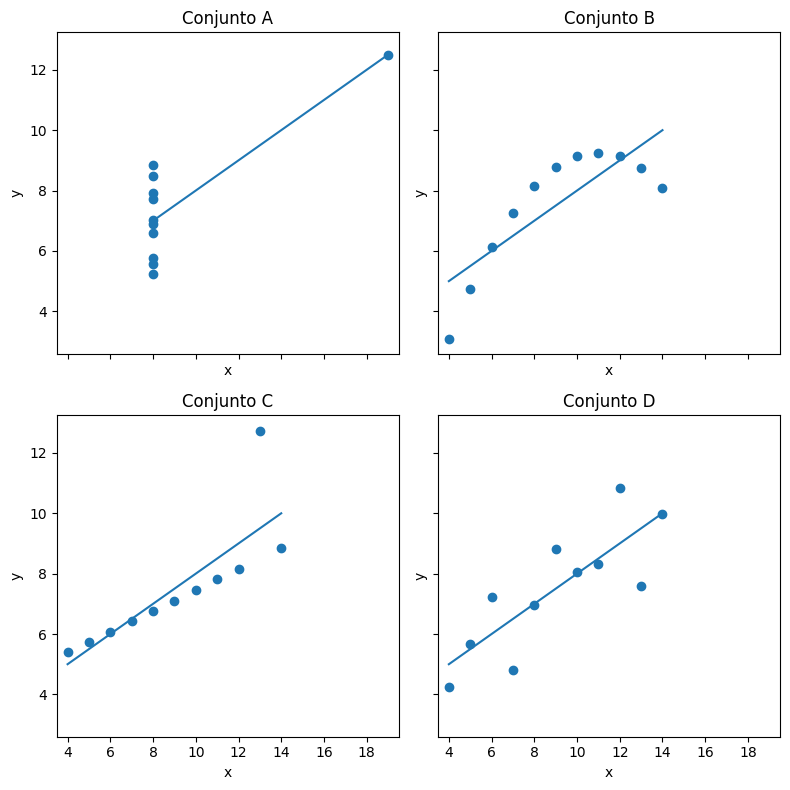

In [11]:
import numpy as np
import matplotlib.pyplot as plt

# Orden consistente A–D
orden = sorted(df_norm['conjunto'].unique(), key=str)

# Figura 2x2
fig, axes = plt.subplots(2, 2, figsize=(8, 8), sharex=True, sharey=True)
axes = axes.ravel()

# Límites comunes para comparación justa
xmin, xmax = df_norm['x'].min() - 0.5, df_norm['x'].max() + 0.5
ymin, ymax = df_norm['y'].min() - 0.5, df_norm['y'].max() + 0.5

for ax, name in zip(axes, orden):
    g = df_norm[df_norm['conjunto'] == name]
    ax.scatter(g['x'], g['y'])
    ax.set_title(f'Conjunto {name}')
    ax.set_xlabel('x'); ax.set_ylabel('y')
    ax.set_xlim(xmin, xmax); ax.set_ylim(ymin, ymax)

    # (Opcional) recta de regresión simple para cada conjunto
    m, b = np.polyfit(g['x'], g['y'], 1)
    xs = np.linspace(g['x'].min(), g['x'].max(), 50)
    ax.plot(xs, m*xs + b)

plt.tight_layout()
plt.show()


**Observaciones:** aunque `x̄`, `ȳ`, `sd(x)`, `sd(y)` y `corr(x,y)` casi coinciden en A–D:
- A luce lineal con dispersión “normal”.
- B sugiere curvatura (no linealidad).
- C muestra un punto atípico que influye la correlación.
- D concentra puntos en un x casi constante y un único punto de alto apalancamiento.

Esto evidencia que **mismas métricas globales** no garantizan **igual patrón** en los datos.


## Paso 7 — Remover 10% aleatorio por conjunto e imputar por media

**Procedimiento:** para cada conjunto (A–D), marco aleatoriamente el 10% de las filas como faltantes y
luego imputo `x` y `y` con la **media del mismo conjunto**.  
**Revisión:** recalculo la tabla de métricas y comparo contra la línea base (sin imputación).
**Reproducibilidad:** semilla fija.


In [12]:
import numpy as np
import pandas as pd

np.random.seed(42)

def inyectar_faltantes_y_imputar(df_in, frac=0.10, seed=42):
    rng = np.random.default_rng(seed)
    df_miss = df_in.copy()
    idx_miss = []

    # 1) elegimos 10% de índices por conjunto
    for nombre, g in df_in.groupby('conjunto'):
        k = max(1, int(np.floor(len(g)*frac)))
        idx = rng.choice(g.index.to_numpy(), size=k, replace=False)
        idx_miss.extend(idx.tolist())
        df_miss.loc[idx, ['x','y']] = np.nan

    # 2) imputamos con la media por conjunto
    medias_grp = df_miss.groupby('conjunto')[['x','y']].transform('mean')
    df_imp = df_miss.fillna(medias_grp)

    return df_imp, idx_miss

# Ejecutar
df_imp, idx_miss = inyectar_faltantes_y_imputar(df_norm, frac=0.10, seed=42)

print("Total imputados:", len(idx_miss))
print("Imputados por conjunto:", df_norm.loc[idx_miss].groupby('conjunto').size().to_dict())
display(df_imp.head())


Total imputados: 4
Imputados por conjunto: {'A': 1, 'B': 1, 'C': 1, 'D': 1}


,conjunto,x,y
0,A,9.1,7.593
1,A,8.0,5.760
2,A,8.0,7.710
3,A,8.0,8.840
4,A,8.0,8.470


In [13]:
def resumen_metricas(df_in):
    tabla = df_in.groupby('conjunto').agg(
        n=('x','size'),
        x_mean=('x','mean'), y_mean=('y','mean'),
        x_std=('x','std'),  y_std=('y','std'),
        x_min=('x','min'),  x_max=('x','max'),
        y_min=('y','min'),  y_max=('y','max'),
    ).round(4)
    corr_xy = (df_in.groupby('conjunto')[['x','y']]
               .apply(lambda g: g['x'].corr(g['y']))
               .rename('corr_xy').round(4))
    # Si calculaste kurtosis antes, agrégala otra vez
    try:
        kurt = df_in.groupby('conjunto').agg(x_kurt=('x', pd.Series.kurt),
                                             y_kurt=('y', pd.Series.kurt)).round(4)
        tabla = tabla.join(kurt)
    except Exception:
        pass
    return tabla.join(corr_xy)

# línea base ya la tienes como `resumen` (Paso 4/5)
resumen_imp = resumen_metricas(df_imp)
resumen_imp


,n,x_mean,y_mean,x_std,y_std,x_min,x_max,y_min,y_max,x_kurt,y_kurt,corr_xy
conjunto,,,,,,,,,,,,
A,11,9.1,7.593,3.3000,2.0075,8.0,19.0,5.25,12.50,10.7037,3.0766,0.8148
B,11,8.7,7.338,3.1639,1.9585,4.0,14.0,3.10,9.26,-0.6923,0.8586,0.8009
C,11,9.5,7.711,2.8723,1.9060,5.0,14.0,5.73,12.74,-0.9111,5.1051,0.7921
D,11,8.8,7.418,3.2496,2.0129,4.0,14.0,4.26,10.84,-0.9427,-0.4033,0.8131


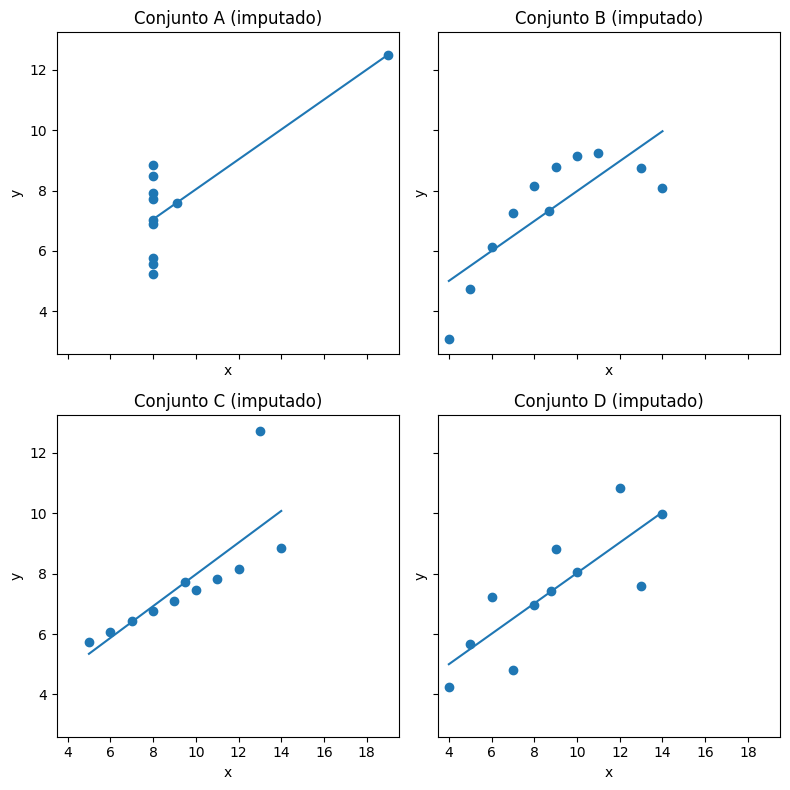

In [14]:
import numpy as np
import matplotlib.pyplot as plt

orden = sorted(df_imp['conjunto'].unique(), key=str)
fig, axes = plt.subplots(2, 2, figsize=(8, 8), sharex=True, sharey=True)
axes = axes.ravel()

xmin, xmax = df_norm['x'].min() - 0.5, df_norm['x'].max() + 0.5
ymin, ymax = df_norm['y'].min() - 0.5, df_norm['y'].max() + 0.5

for ax, name in zip(axes, orden):
    g = df_imp[df_imp['conjunto'] == name]
    ax.scatter(g['x'], g['y'])  # puntos (algunos imputados caen en el centro)
    ax.set_title(f'Conjunto {name} (imputado)')
    ax.set_xlabel('x'); ax.set_ylabel('y')
    ax.set_xlim(xmin, xmax); ax.set_ylim(ymin, ymax)

    # recta de regresión (opcional)
    m, b = np.polyfit(g['x'], g['y'], 1)
    xs = np.linspace(g['x'].min(), g['x'].max(), 50)
    ax.plot(xs, m*xs + b)

plt.tight_layout(); plt.show()


### Comentario — Efecto de la imputación por media (10% por conjunto)

- La **media** de cada coordenada apenas cambia (esperable: reponemos con la misma media del grupo).
- Las **desviaciones estándar** tienden a **disminuir** (los puntos imputados caen en el centro → menos dispersión).
- La **correlación** `corr(x,y)` puede **moverse** (usualmente se reduce levemente) porque los puntos imputados
  no respetan la estructura original de dependencia.
- Los **extremos** (`min`, `max`) pueden acercarse al centro si alguno fue imputado, y la **kurtosis** suele bajar
  (colas menos pesadas).
- Visualmente, los conjuntos se ven **más compactos** alrededor de la media; se “suavizan” outliers y curvas.
  
**Conclusión:** imputar con la media preserva la ubicación central, pero **distorsiona la forma** (dispersión,
dependencia y colas). Por eso conviene reportar qué porcentaje fue imputado y, si es sensible, considerar
métodos de imputación más fieles a la estructura (p. ej., kNN, regresión o por patrón de cada conjunto).
